# **🌳 '경제 지수'와 관련된 데이터셋 입니다.**

미국의 증시와 우리나라의 경제는 어떤 관련을 지니고 있는지 '두 나라의 경제 지수'를 통해 국가 간의 상호 의존성을 파악하는 모델을 제작하려한다.

- 대한민국 경제지수(KOSPI), 미국 경제지수(Dow Jones)의 상관관계를 파악하여 우리나라의 경제 성장을 예측해봅시다!

✔️ **[파일] - [Drive에 사본 저장]**

# **[단계1] 데이터 불러오기**

📍 **야후 파이낸스**? 코스피 지수와 다우존스 지수의 데이터 사용하기 위해 금융 파이썬 사용 → 금융  데이터 API를 통해 무료로 시세 데이터를 제공해줌.

- **금융 데이터 API**? 원하는 금융 데이터를 요청하면 이에 맞는 응답 데이터를 보내주는 것.

→ 우리는 이 과정에서 '파이썬'을 사용해 그 요청과 응답을 수행해야하는데, 야후 파이낸스 API를 파이썬으로 사용 가능하게 만들어준 것이 yfinance임!

In [ ]:
import pandas as pd
import yfinance as yf # 금융 파이썬 라이브러리

dow = yf.download('^DJI', start = '2024-01-01', end = '2026-03-20') #다우존스 데이터
kospi = yf.download('^KS11', start = '2024-0g1-01', end = '2026-03-20') #코스피 데이터

/tmp/ipykernel_217/25015010.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dow = yf.download('^DJI', start = '2024-01-01', end = '2026-03-20') #다우존스 데이터
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_217/25015010.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  kospi = yf.download('^KS11', start = '2024-01-01', end = '2026-03-20') #코스피 데이터
[*********************100%***********************]  1 of 1 completed


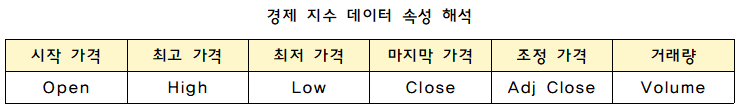

In [ ]:
dow.head(3) # 데이터 확인하기(다우존스 지수)

Price,Close,High,Low,Open,Volume
Ticker,^DJI,^DJI,^DJI,^DJI,^DJI
Date,,,,,
2024-01-02,37715.039062,37790.078125,37495.910156,37566.218750,350280000
2024-01-03,37430.191406,37629.230469,37401.851562,37629.230469,322010000
2024-01-04,37440.339844,37716.410156,37425.281250,37425.281250,380220000


In [ ]:
kospi.head(3) # 데이터 확인하기(코스피 지수)

Price,Close,High,Low,Open,Volume
Ticker,^KS11,^KS11,^KS11,^KS11,^KS11
Date,,,,,
2024-01-02,2669.810059,2675.800049,2641.879883,2645.469971,409900
2024-01-03,2607.310059,2643.719971,2607.310059,2643.540039,463100
2024-01-04,2587.020020,2602.639893,2580.090088,2592.439941,770200


# **[단계2] 데이터 시각화 하기**

종가? 증권 시장에서의 마지막 가격(=Close)

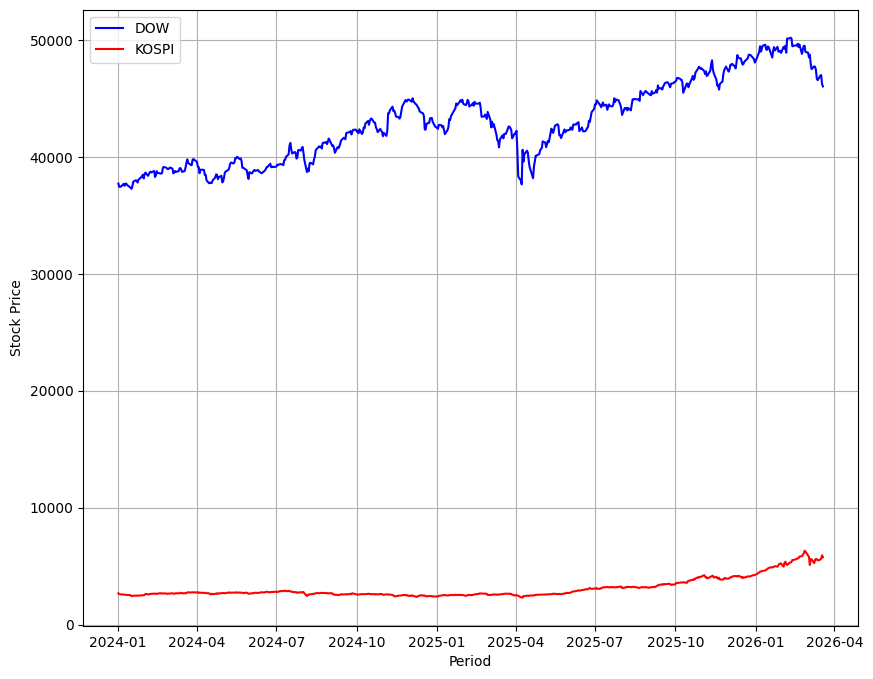

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 8)) # 그래프 크기 설정
plt.plot(dow.index, dow.Close, 'b', label = 'DOW') # 다우존스 지수의 종가
plt.plot(kospi.index, kospi.Close, 'r', label = 'KOSPI') # 코스피 지수의 종가
plt.grid(True) # 그래프에 격자 추가(시계열이나 산점도에서 추가하면 범위 읽기 좋음!)
plt.xlabel('Period') # x축 이름 = Period(날짜)
plt.ylabel('Stock Price') # y축 이름 = Stock Price(주가)
plt.legend(loc = 'best') # 범례의 위치를 자동으로 가장 적절한 곳으로 배치
plt.show()

✔️ 위 그래프에서 알 수 있는 점?

두 지수의 가격 차이가 많이 나서 함께 비교하기가 여려움.

→ 가격의 변동 정도를 비교해서 두 지수가 서로 비슷한 움직임을 보이는지 파악해야함.

→ 각 데이터의 현재 종가를 특정 시점의 종가로 나누어 **백분율**을 구해야한다!

==

<Gemini의 해석 도움>
1. **체급의 차이 (절대값의 함정)**

그래프에서 DOW 지수가 1,000포인트 움직이는 것과 KOSPI 지수가 1,000포인트 움직이는 것은 완전히 다른 의미입니다.

DOW: 40,000에서 1,000이 오르면 약 2.5% 상승한 것입니다.

KOSPI: 2,500에서 1,000이 오르면 무려 **40%**나 폭등한 것입니다.

현재 그래프처럼 절대적인 가격(Stock Price)으로만 그리면, KOSPI가 아무리 역동적으로 움직여도 DOW의 미세한 흔들림보다 작게 보여서 변동의 흐름을 놓치게 됩니다.

2. **가시성의 문제**

지금 그래프를 보시면 KOSPI 선은 거의 일직선처럼 보이죠? 하지만 실제로 KOSPI 내부에서도 10%가 오르내리는 큰 변화가 있었을 겁니다. DOW의 수치 범위(0~50,000)에 맞춰져 있다 보니, 상대적으로 숫자가 작은 KOSPI의 굴곡이 다 펴져 버리는 현상이 발생한 거예요.

3. **수익률 비교의 핵심: 백분율(지수화)**

투자자 입장에서 중요한 건 "내가 100만 원을 넣었을 때 어디서 더 많이 벌었나?"입니다. 이를 확인하려면 두 지수의 시작점을 똑같이 **100(또는 0%)**으로 맞추는 작업이 필요합니다.

예시:

A 지수: 40,000원 → 44,000원 (4,000원 상승, +10%)

B 지수: 2,000원 → 2,400원 (400원 상승, +20%)

그냥 보면 A가 많이 오른 것 같지만, 백분율로 바꾸면 B의 수익률이 2배나 높다는 것이 명확해집니다.

# **[단계3] 데이터 전처리 ① (데이터 크기 변경) → 데이터 시각화**

In [ ]:
dow_d = (dow.Close / dow.Close.iloc[0]) * 100 # 다우존스 지수를 첫 번째 종가를 기준으로 백분율 구하기
kospi_k = (kospi.Close / kospi.Close.iloc[0]) * 100 # 코스피 지수를 첫 번째 종가를 기준으로 백분율 구하기

✔️ 코스피 지수와 다우존스 지수의 상관관계가 어느 정도인지 파악하기 위해 '**산점도**' 그려보기

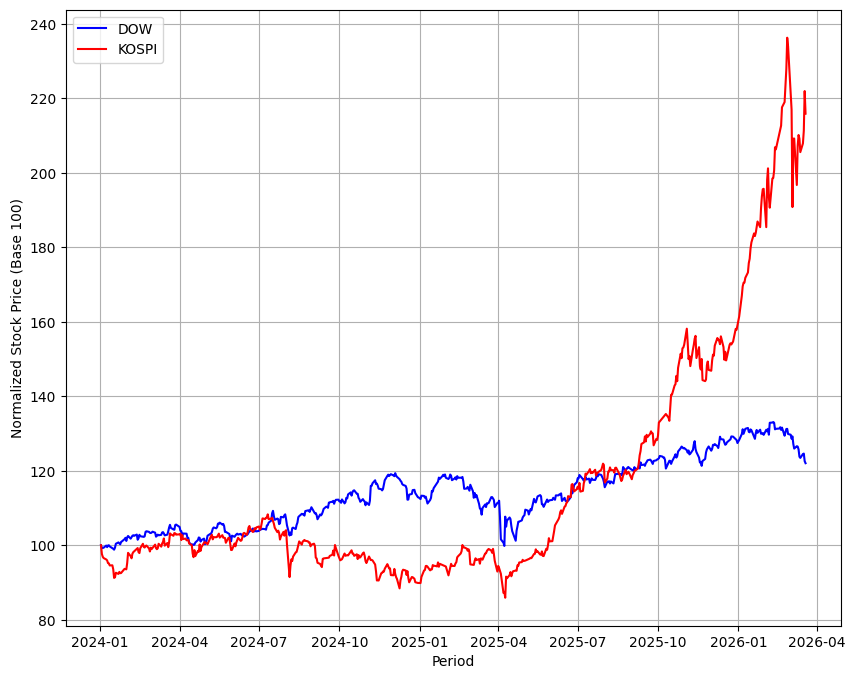

In [ ]:
plt.figure(figsize = (10, 8)) # 그래프 크기 설정
plt.plot(dow_d.index, dow_d.iloc[:, 0], 'b', label = 'DOW') # 다우존스 지수의 정규화된 값
plt.plot(kospi_k.index, kospi_k.iloc[:, 0], 'r', label = 'KOSPI') # 코스피 지수의 정규화된 값
plt.grid(True) # 그래프에 격자 추가(시계열이나 산점도에서 추가하면 범위 읽기 좋음!)
plt.xlabel('Period') # x축 이름 = Period(날짜)
plt.ylabel('Normalized Stock Price (Base 100)') # y축 이름 = 정규화된 주가
plt.legend(loc = 'best') # 범례의 위치를 자동으로 가장 적절한 곳으로 배치
plt.show()

# **[단계3] 데이터 전처리 ② (새로운 데이터 프레임 생성)**

In [ ]:
# 두 나라의 경제 지수를 정확하게 비교하고 분석하기 위함
if isinstance(dow.columns, pd.MultiIndex):
    dow.columns = dow.columns.get_level_values(0)
if isinstance(kospi.columns, pd.MultiIndex):
    kospi.columns = kospi.columns.get_level_values(0)

# 두 시장의 휴일이 다르기 때문에 다우존스 지수와 코스피 지수 데이터의 날짜 인덱스가 서로 일치하지 않아 한쪽 지수만 데이터가 있을 수 있기 때문에 결측치 발생
df = pd.DataFrame({'DOW': dow['Close'], 'KOSPI': kospi['Close']}).dropna()
df

,DOW,KOSPI
Date,,
2024-01-02,37715.039062,2669.810059
2024-01-03,37430.191406,2607.310059
2024-01-04,37440.339844,2587.020020
2024-01-05,37466.109375,2578.080078
2024-01-08,37683.011719,2567.820068
...,...,...
2026-03-13,46558.468750,5487.240234
2026-03-16,46946.410156,5549.850098
2026-03-17,46993.261719,5640.479980


<조건문에 대한 Gemini 해석 도움>

다우존스(미국)와 코스피(한국) 데이터를 가져왔는데, 컴퓨터는 이 데이터들을 바로 가져다가 합치거나 계산하기 전에 **'데이터의 생김새'**를 확인해요. 그런데 yfinance에서 주는 데이터는 때때로 컬럼(항목 이름)이 좀 복잡하게 생겨서, 컴퓨터가 '어떤 것이 진짜 가격 정보인지' 헷갈릴 때가 있어요. 이걸 'MultiIndex'라고 부르는데, 마치 보물 상자의 꼬리표가 여러 겹으로 붙어있는 것처럼요.

이 if isinstance 코드는 바로 그 복잡한 꼬리표를 '가격'이라는 하나의 단순한 꼬리표로 정리해주는 역할을 해요. 이렇게 데이터를 깔끔하게 정리해줘야 컴퓨터가 오류 없이 두 지수의 '최종 가격'만 정확히 뽑아서 합치고, 나중에 상관관계를 분석하는 등 우리가 원하는 작업을 제대로 할 수 있답니다. 만약 이 작업을 하지 않으면, 컴퓨터는 '데이터가 너무 복잡해서 뭘 해야 할지 모르겠어!'라며 오류를 낼 거예요.

In [ ]:
df.isnull().sum()

,0
DOW,0
KOSPI,0


# **[단계3] 데이터 전처리 ③ (데이터 크기 변경)**

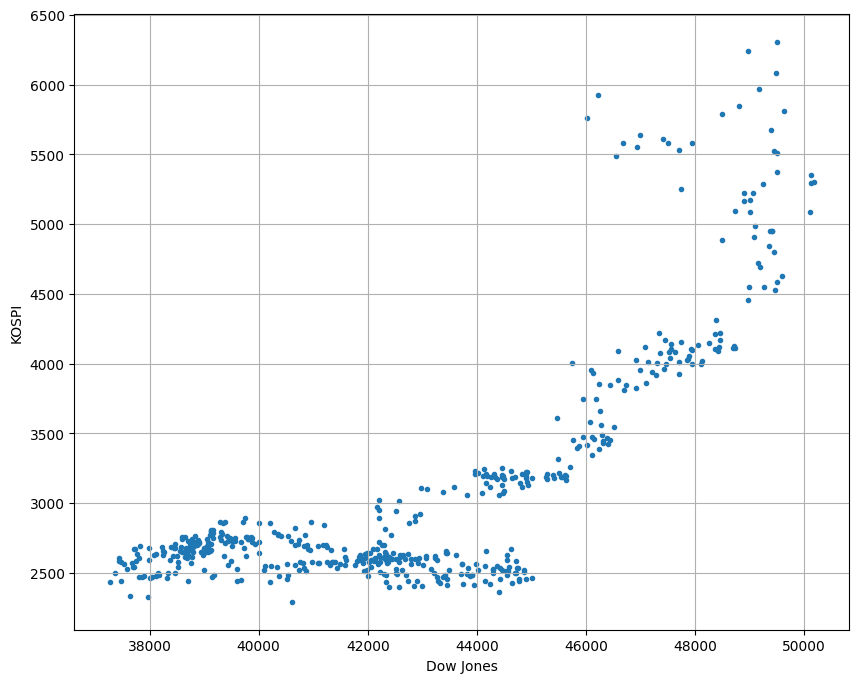

In [ ]:
plt.figure(figsize = (10, 8))
plt.scatter(df['DOW'], df['KOSPI'], marker = '.')
plt.grid(True)
plt.xlabel('Dow Jones')
plt.ylabel('KOSPI')
plt.show()

📍**StandardScaler 라이브러리**?

서로 다른 범위의 데이터 값을 비슷한 범위의 값으로 조정

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_std = scaler.fit_transform(df)
df_std = pd.DataFrame(df_std, columns = ['DOW', 'KOSPI'])
df_std.head(3)

,DOW,KOSPI
0,-1.506645,-0.509377
1,-1.589127,-0.582503
2,-1.586188,-0.606242


# **[단계4] 독립변수와 종속변수 설정하기**

In [ ]:
X = df_std[['DOW']]
Y = df_std['KOSPI']

# **[단계5] 데이터 쪼개기**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1234)

# **[단계6] 선형회귀 모델 제작**

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

# **[단계7-1] 모델 성능 평가**

In [ ]:
from sklearn.metrics import mean_squared_error #MSE를 계산 및 확인하기 위한 라이브러리
import numpy as np

Predicted = model.predict(X_test) #모델 예측
MSE = mean_squared_error(Y_test, Predicted)
RMSE = np.sqrt(MSE) #sqrt() = 제곱근

print(f"MSE(평균제곱오차): {MSE:.2f}")
print(f"RMSE(평균제곱근오차): {RMSE:.2f}")

MSE(평균제곱오차): 0.38
RMSE(평균제곱근오차): 0.61


In [ ]:
#(참고) 모델이 예측한 값
print(Y_pred)

[ 7.60525459e-01 -5.91097974e-01  4.10791189e-01 -5.33619940e-01
 -1.19328737e+00 -1.13632141e+00  1.14035104e-02 -1.01312729e+00
 -5.21839508e-01  7.91778221e-01  1.82880722e-01 -1.81649936e-01
 -8.77141144e-01  3.72745129e-01 -9.47125125e-01 -9.59216431e-02
 -8.63807445e-01 -7.29843592e-01  1.01839639e+00  1.04891288e+00
 -7.17533148e-01 -1.39101016e-01  3.03512670e-01  4.16661676e-01
 -1.19881797e+00  7.32027682e-01 -5.88602166e-01  1.64906832e+00
 -1.01683468e+00  1.49669664e+00  3.38312296e-01 -1.25447100e+00
 -1.06985470e+00 -6.88215692e-01 -1.45339193e-01 -1.64600773e-01
  1.36824276e+00  3.60371011e-01 -1.52141460e-01  1.38769088e+00
 -1.13559590e+00  1.04882889e-01 -9.29597966e-01 -9.54978448e-01
  3.70389221e-01 -9.68962330e-01 -9.03428296e-01 -1.68735942e-01
  1.32657361e+00 -8.87908186e-01  3.72676075e-01 -9.82229665e-01
 -3.09674248e-01 -3.92579080e-02  8.07098342e-01  5.84709504e-01
 -1.04383390e+00  8.05452705e-01 -6.73102732e-01 -3.22995970e-02
 -8.02248630e-02  3.00294

# **[단계7-2] 모델 성능 평가 예측값 시각화하기**

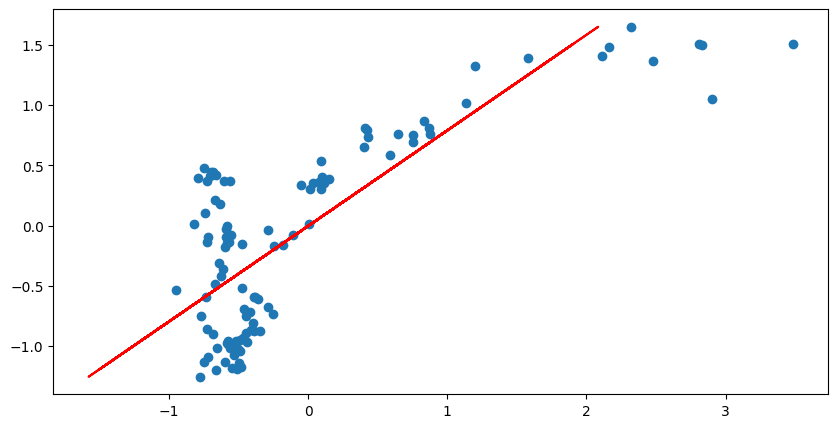

In [ ]:
plt.figure(figsize = (10, 5))
plt.scatter(Y_test, Y_pred)
plt.plot(X_test, Y_pred, color = 'red')
plt.show()

In [ ]:
#(참고) 실젯값 처음 다섯 개 출력
Y.head(2)

,KOSPI
0,-0.509377
1,-0.582503


In [ ]:
model.score(X_test, Y_test) # 결정계수 확인

0.5688577461306081